# JJava interactive Swing demos

Requires the `jjava-swing` JupyterLab extension. Run each cell and interact with the output.

1. **Bouncing balls** — animation + buttons + click-to-add
2. **Sketch pad** — mouse drag + custom painting + toolbar
3. **Form** — keyboard/focus stress test (the fragile path)

## 1. Bouncing balls (animation streaming + buttons + mouse)

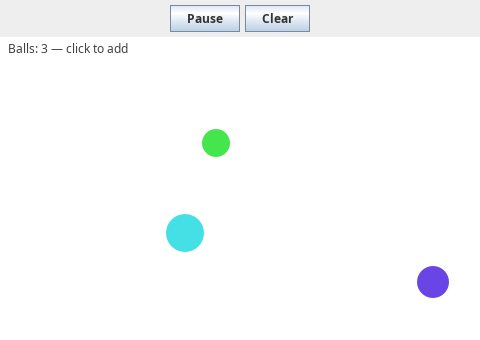

In [1]:
// Demo 1 — animation + buttons + mouse.
// Exercises: Swing Timer driving continuous repaints (async frame streaming via the custom RepaintManager),
// button clicks (Pause/Clear), and mouse clicks (click the canvas to add a ball).
import javax.swing.*;
import java.awt.*;
import java.awt.event.*;
import java.util.*;
import java.util.List;
import javax.swing.Timer; // disambiguate: java.util.Timer is auto-imported by the notebook

class BallsPanel extends JPanel {
    class Ball { double x, y, vx, vy; int r; Color c; }
    final List<Ball> balls = new ArrayList<>();
    final Random rnd = new Random();
    final Timer timer;

    BallsPanel() {
        setPreferredSize(new Dimension(480, 300));
        setBackground(Color.WHITE);
        for (int i = 0; i < 3; i++) addBall(rnd.nextInt(480), rnd.nextInt(300));
        addMouseListener(new MouseAdapter() {
            public void mousePressed(MouseEvent e) { addBall(e.getX(), e.getY()); repaint(); }
        });
        timer = new Timer(16, e -> { step(); repaint(); });
        timer.start();
    }

    void addBall(int x, int y) {
        Ball b = new Ball();
        b.x = x; b.y = y;
        b.vx = rnd.nextDouble() * 8 - 4;
        b.vy = rnd.nextDouble() * 8 - 4;
        b.r = 8 + rnd.nextInt(22);
        b.c = Color.getHSBColor(rnd.nextFloat(), 0.7f, 0.9f);
        balls.add(b);
    }

    void step() {
        int w = getWidth(), h = getHeight();
        for (Ball b : balls) {
            b.x += b.vx; b.y += b.vy;
            if (b.x - b.r < 0 || b.x + b.r > w) b.vx = -b.vx;
            if (b.y - b.r < 0 || b.y + b.r > h) b.vy = -b.vy;
        }
    }

    protected void paintComponent(Graphics g) {
        super.paintComponent(g);
        Graphics2D g2 = (Graphics2D) g;
        g2.setRenderingHint(RenderingHints.KEY_ANTIALIASING, RenderingHints.VALUE_ANTIALIAS_ON);
        for (Ball b : balls) {
            g2.setColor(b.c);
            g2.fillOval((int) (b.x - b.r), (int) (b.y - b.r), b.r * 2, b.r * 2);
        }
        g2.setColor(Color.DARK_GRAY);
        g2.drawString("Balls: " + balls.size() + " — click to add", 8, 16);
    }
}

BallsPanel canvas = new BallsPanel();

JButton toggle = new JButton("Pause");
toggle.addActionListener(e -> {
    if (canvas.timer.isRunning()) { canvas.timer.stop(); toggle.setText("Start"); }
    else { canvas.timer.start(); toggle.setText("Pause"); }
});
JButton clear = new JButton("Clear");
clear.addActionListener(e -> { canvas.balls.clear(); canvas.repaint(); });

JPanel root = new JPanel(new BorderLayout());
JPanel bar = new JPanel();
bar.add(toggle); bar.add(clear);
root.add(bar, BorderLayout.NORTH);
root.add(canvas, BorderLayout.CENTER);
root.setPreferredSize(new Dimension(480, 340));

displayInteractive(root);


## 2. Sketch pad (mouse drag + custom paint + toolbar)

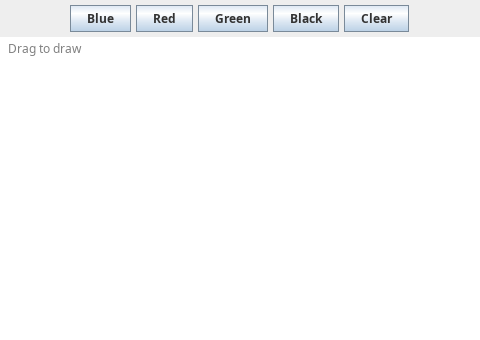

In [2]:
// Demo 2 — mouse drag + custom painting + a color/clear toolbar.
// Exercises: mousePressed/mouseDragged (free-hand drawing), repaint-on-drag streaming, and button clicks.
import javax.swing.*;
import java.awt.*;
import java.awt.event.*;
import java.util.*;
import java.util.List;

class SketchPad extends JPanel {
    static class Stroke { Color color; List<Point> points = new ArrayList<>(); }
    final List<Stroke> strokes = new ArrayList<>();
    Stroke current;
    Color color = new Color(0x1565C0);

    SketchPad() {
        setPreferredSize(new Dimension(480, 300));
        setBackground(Color.WHITE);
        MouseAdapter ma = new MouseAdapter() {
            public void mousePressed(MouseEvent e) {
                current = new Stroke();
                current.color = color;
                current.points.add(e.getPoint());
                strokes.add(current);
                repaint();
            }
            public void mouseDragged(MouseEvent e) {
                if (current != null) { current.points.add(e.getPoint()); repaint(); }
            }
            public void mouseReleased(MouseEvent e) { current = null; }
        };
        addMouseListener(ma);
        addMouseMotionListener(ma);
    }

    protected void paintComponent(Graphics g) {
        super.paintComponent(g);
        Graphics2D g2 = (Graphics2D) g;
        g2.setRenderingHint(RenderingHints.KEY_ANTIALIASING, RenderingHints.VALUE_ANTIALIAS_ON);
        g2.setStroke(new BasicStroke(3, BasicStroke.CAP_ROUND, BasicStroke.JOIN_ROUND));
        for (Stroke s : strokes) {
            g2.setColor(s.color);
            for (int i = 1; i < s.points.size(); i++) {
                Point a = s.points.get(i - 1), b = s.points.get(i);
                g2.drawLine(a.x, a.y, b.x, b.y);
            }
        }
        g2.setColor(Color.GRAY);
        g2.drawString("Drag to draw", 8, 16);
    }
}

SketchPad pad = new SketchPad();

JPanel bar = new JPanel();
for (Object[] sw : new Object[][]{{"Blue", new Color(0x1565C0)}, {"Red", new Color(0xC62828)}, {"Green", new Color(0x2E7D32)}, {"Black", Color.BLACK}}) {
    JButton b = new JButton((String) sw[0]);
    Color c = (Color) sw[1];
    b.addActionListener(e -> pad.color = c);
    bar.add(b);
}
JButton clear = new JButton("Clear");
clear.addActionListener(e -> { pad.strokes.clear(); pad.repaint(); });
bar.add(clear);

JPanel root = new JPanel(new BorderLayout());
root.add(bar, BorderLayout.NORTH);
root.add(pad, BorderLayout.CENTER);
root.setPreferredSize(new Dimension(480, 340));

displayInteractive(root);


## 3. Form (keyboard + focus + slider) — stress test

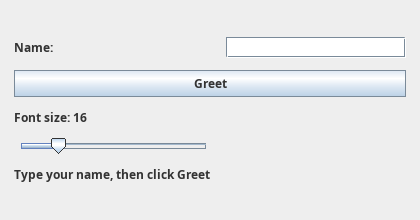

In [1]:
import javax.swing.*;
import java.awt.*;

// 1. We renamed the panel to 'demoPanel' to bypass any stale memory in the REPL
JPanel demoPanel = new JPanel(new GridBagLayout());
demoPanel.setPreferredSize(new Dimension(420, 220));

JTextField name = new JTextField(16);
JLabel greeting = new JLabel("Type your name, then click Greet");
JButton greet = new JButton("Greet");
greet.addActionListener(e -> greeting.setText("Hello, " + name.getText() + "!"));

JSlider size = new JSlider(8, 48, 16);
JLabel sizeLabel = new JLabel("Font size: 16");
size.addChangeListener(e -> {
    int v = size.getValue();
    sizeLabel.setText("Font size: " + v);
    greeting.setFont(greeting.getFont().deriveFont((float) v));
});

GridBagConstraints gc = new GridBagConstraints();
gc.insets = new Insets(6, 6, 6, 6);
gc.fill = GridBagConstraints.HORIZONTAL;

// 2. All components are now added to the newly named 'demoPanel'
gc.gridx = 0; gc.gridy = 0; 
demoPanel.add(new JLabel("Name:"), gc);

gc.gridx = 1; gc.gridy = 0; 
demoPanel.add(name, gc);

gc.gridx = 0; gc.gridy = 1; gc.gridwidth = 2; 
demoPanel.add(greet, gc);

gc.gridx = 0; gc.gridy = 2; gc.gridwidth = 1; 
demoPanel.add(sizeLabel, gc);

gc.gridx = 0; gc.gridy = 3; 
demoPanel.add(size, gc);

gc.gridx = 0; gc.gridy = 4; 
demoPanel.add(greeting, gc);

// 3. Pass the new panel to your environment's display method
displayInteractive(demoPanel);